<a href="https://colab.research.google.com/github/IrineuBovoJunior398/Pos-em-IA/blob/main/TAREFA1_AUTOENCODERS_PRATICA_BLOCO5_FASHION_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import fashion_mnist
from keras.layers import Dense, Input, Dropout
from keras.models import Model
from keras.models import Sequential

In [ ]:
# Carregando o conjunto de dados do Fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

valMax = x_train.max()
print(valMax)

valMin = x_train.min()
print(valMin)

# Normalizando os valores dos pixels para o intervalo [0, 1]
x_train = x_train / valMax
x_test = x_test / valMax

# Transformando as imagens em vetores unidimensionais (784 Pixels)
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)
255
0
(60000, 784)
(10000, 784)


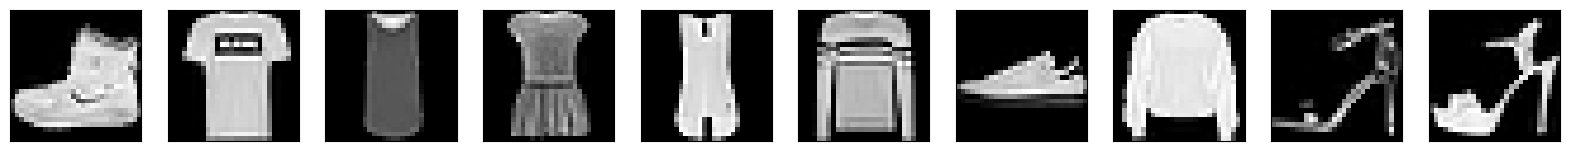

In [ ]:
# Visualizando algumas imagens originais
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
  # Imagem de entrada com ruído
  ax = plt.subplot(2, n, i + 1)
  plt.imshow(x_train[i].reshape(28, 28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()

(60000, 784)
(10000, 784)


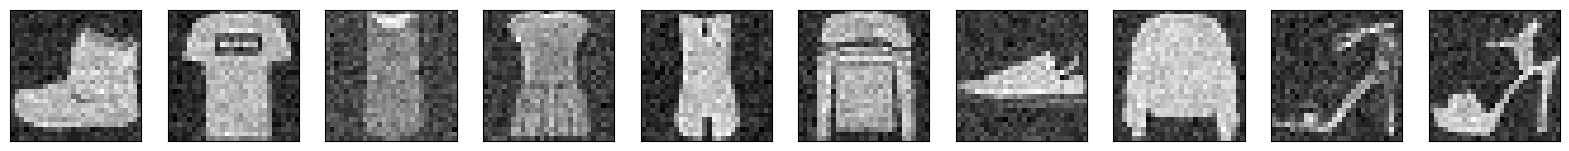

In [ ]:
# Aplicação de ruído nos dados e armazenando em variáveis acessórias
factor = 0.1

x_train_noisy = x_train + factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

print(x_train_noisy.shape)
print(x_test_noisy.shape)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
  # Imagem de entrada com ruído
  ax = plt.subplot(2, n, i + 1)
  plt.imshow(x_train_noisy[i].reshape(28, 28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()

In [ ]:
# CONSTRUÇÃO DO MODELO AUTOENCODER COM DADOS ORIGINAIS
# DEFININDO A DIMENSÃO DA REPRESENTAÇÃO CODIFICADA
n_latent = 60
dim_input = x_train.shape[1]

# CRIANDO O MODELO DO AUTOENCODER
model = Sequential()
model.add(Dense(units = 400, input_dim = dim_input,activation="relu"))
model.add(Dense(units = 200, activation="relu"))
model.add(Dense(units = n_latent, activation="relu"))
model.add(Dense(units = 200, activation="relu"))
model.add(Dense(units = 400, activation="relu"))
model.add(Dense(units = dim_input, activation="sigmoid"))

# COMPILANDO O MODELO
model.compile(optimizer="adam", loss="binary_crossentropy")

# TREINAMENTO
model.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))


# CLASSIFICANDO E DECODIFICANDO AS IMAGENS DE TESTE SEM RUÍDO
encoded_imgs = model.predict(x_test)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - loss: 0.3540 - val_loss: 0.3089
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 0.2987 - val_loss: 0.2961
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 0.2899 - val_loss: 0.2901
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - loss: 0.2851 - val_loss: 0.2850
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - loss: 0.2817 - val_loss: 0.2823
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - loss: 0.2792 - val_loss: 0.2810
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 0.2775 - val_loss: 0.2788
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 0.2759 - val_loss: 0.2786
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - loss: 0.2745 - val_loss: 0.2763
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - loss: 0.2734 - val_loss: 0.2758
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 0.2726 - val_loss: 0.2746
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


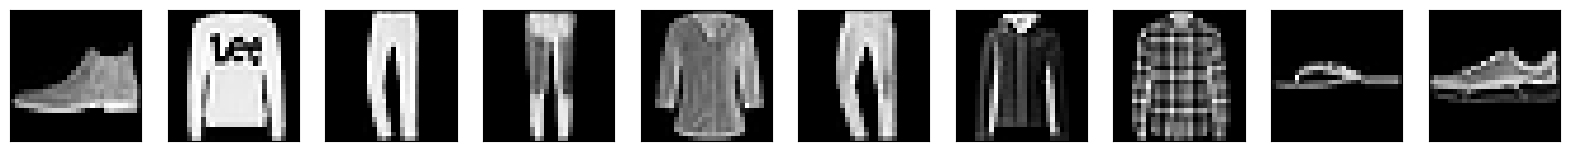

In [ ]:
# OBTER IMAGENS RECONSTRUIDAS
decoded_imgs = model.predict(x_test_noisy)

# PLOTANDO AS IMAGENS RECONSTRUIDAS
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
  #Imagem original
  ax = plt.subplot(2, n, i + 1)
  plt.imshow(x_test[i].reshape(28, 28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()

In [ ]:
# CODIFICANDO E DECODIFICANDO AS IMAGENS DE TESTE COM RUÍDO
encoded_imgs_noisy = model.predict(x_test_noisy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


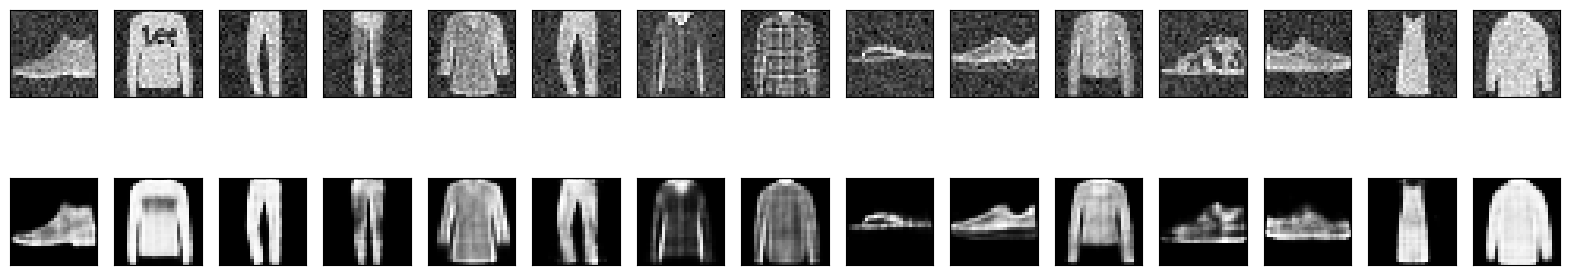

In [ ]:
import matplotlib.pyplot as plt

n = 15
plt.figure(figsize=(20, 4))

for i in range(n):
    # 1. IMAGEM COM RUÍDO (Linha 1)
    ax = plt.subplot(2, n, i + 1) # i + 1 coloca na primeira linha
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # 2. IMAGEM RECONSTRUÍDA (Linha 2)
    ax = plt.subplot(2, n, i + 1 + n) # i + 1 + n pula para a segunda linha
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

In [ ]:
# Criando um Modelo de Classificação para testar as amostras ruidosas, amostras originais e as amostras recuperadas do ruído
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# 1. Preparar os labels (One-hot encoding)
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# 2. Definir a arquitetura do Classificador
classifier = Sequential([
    Dense(512, activation='relu', input_dim=784),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax') # 10 classes de saída
])

classifier.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

# 3. Treinar com dados originais (limpos)
classifier.fit(x_train, y_train_cat, epochs=10, batch_size=256, verbose=1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8079 - loss: 0.5387
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8603 - loss: 0.3835
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8734 - loss: 0.3453
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8815 - loss: 0.3222
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8866 - loss: 0.3073
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8897 - loss: 0.2932
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8941 - loss: 0.2803
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8978 - loss: 0.2713
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9006 - loss: 0.2642
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9046 - loss: 0.2526


In [ ]:
# Avaliação 1: Imagens Originais
score_orig = classifier.evaluate(x_test, y_test_cat, verbose=0)
print(f"Acurácia (Original): {score_orig[1]*100:.2f}%")

# Avaliação 2: Imagens com Ruído
# (Certifique-se de que x_test_noisy está no formato (10000, 784))
score_noisy = classifier.evaluate(x_test_noisy, y_test_cat, verbose=0)
print(f"Acurácia (Com Ruído): {score_noisy[1]*100:.2f}%")

# Avaliação 3: Imagens Recuperadas (Denoised)
# decoded_imgs é o que saiu do seu model.predict()
score_recovered = classifier.evaluate(decoded_imgs, y_test_cat, verbose=0)
print(f"Acurácia (Recuperada): {score_recovered[1]*100:.2f}%")

Acurácia (Original): 89.06%
Acurácia (Com Ruído): 88.37%
Acurácia (Recuperada): 86.72%


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
------------------------------
AVALIAÇÃO DA CLASSIFICAÇÃO
------------------------------
Acurácia: 0.8906
MSE: 1.4560

Relatório de Classificação:
              precision    recall  f1-score   support

    Camiseta       0.87      0.83      0.85      1000
       Calça       0.98      0.98      0.98      1000
    Pullover       0.76      0.85      0.80      1000
     Vestido       0.91      0.89      0.90      1000
      Casaco       0.80      0.81      0.80      1000
    Sandália       0.99      0.95      0.97      1000
      Camisa       0.75      0.69      0.72      1000
       Tênis       0.92      0.98      0.95      1000
       Bolsa       0.96      0.98      0.97      1000
        Bota       0.97      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

Gerando Matriz de Confusão...


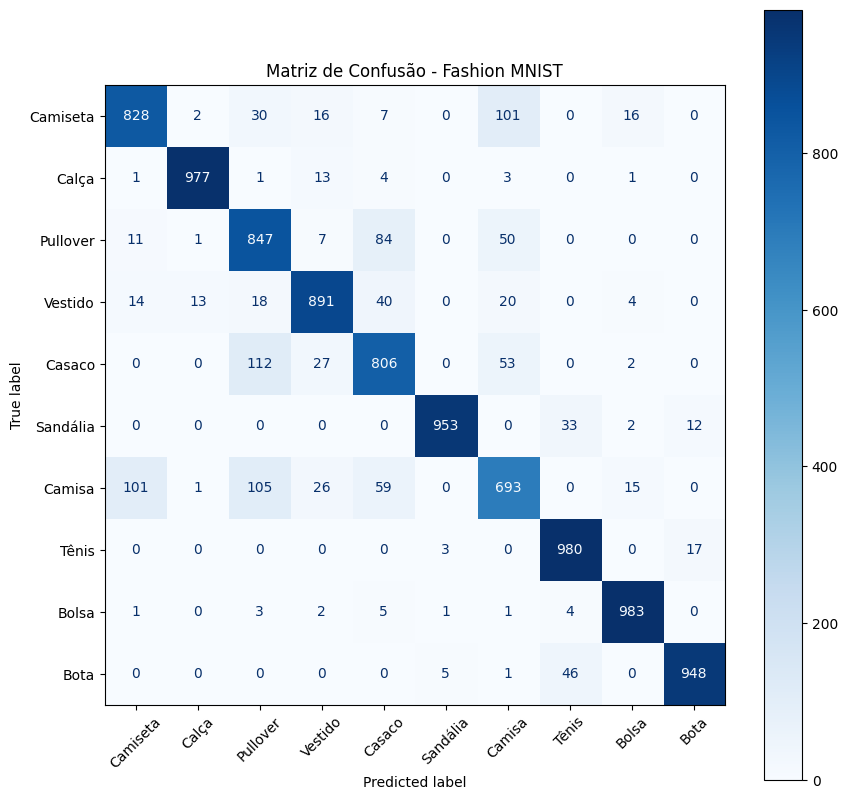

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error, ConfusionMatrixDisplay

# 1. Gerar as previsões (Probabilidades)
y_probs = classifier.predict(x_test)

# 2. Converter probabilidades para classes (O maior valor é a classe escolhida)
y_pred = np.argmax(y_probs, axis=1)

print("-" * 30)
print("AVALIAÇÃO DA CLASSIFICAÇÃO")
print("-" * 30)

# Acurácia Global
acc = accuracy_score(y_test, y_pred)
print(f"Acurácia: {acc:.4f}")

# MSE (Interpretado com cautela em classificação)
mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse:.4f}")

print("\nRelatório de Classificação:")
target_names = ["Camiseta", "Calça", "Pullover", "Vestido", "Casaco",
                "Sandália", "Camisa", "Tênis", "Bolsa", "Bota"]

print(classification_report(y_test, y_pred, target_names=target_names))

# --- VISUALIZAÇÃO DA MATRIZ DE CONFUSÃO ---
print("Gerando Matriz de Confusão...")
fig, ax = plt.subplots(figsize=(10, 10))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(xticks_rotation=45, cmap=plt.cm.Blues, ax=ax)
plt.title("Matriz de Confusão - Fashion MNIST")
plt.show()